<a href="https://colab.research.google.com/github/Rogelio756/Equipo8-Grupo8-SIC-2025-/blob/CLAHE-%2B-RETINEX/CLAHE_RETINEX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#En el siguiente codigo se enlista el proceso para el preprocesado de las imágenes y la aplicación de filtros CLAHE y Retinex


Montar el Drive en google colab


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/AI_PROJECT/scaled_images.zip" -d "/content/dataset_local"

In [ ]:
import os

ruta_imagenes = '/content/dataset_local'
archivos = os.listdir(ruta_imagenes)
print(f"Total de imágenes: {len(archivos)}")
print(f"Ejemplo de archivo: {archivos[0]}")

Total de imágenes: 69863
Ejemplo de archivo: scaled_day_34c22b29-b81f8ad4.jpg


Extracción y verificación de las primeras 5 imagenes del dataset

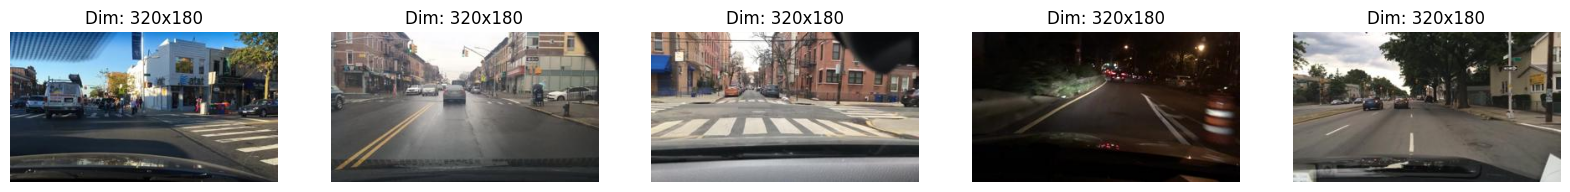

In [ ]:
import matplotlib.pyplot as plt
import cv2

ruta_imagenes = '/content/dataset_local'
archivos = [f for f in os.listdir(ruta_imagenes) if f.endswith(('.jpg', '.jpeg', '.png'))]
n_imagenes = 5
plt.figure(figsize=(20, 10))

for i in range(n_imagenes):
    path = os.path.join(ruta_imagenes, archivos[i])
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, n_imagenes, i + 1)
    plt.imshow(img_rgb)
    alto, ancho, canales = img.shape
    plt.title(f"Dim: {ancho}x{alto}")
    plt.axis('off')
plt.show()

Verificación de nombres de las imagenes

In [ ]:

ruta_imagenes = '/content/dataset_local'
archivos = [f for f in os.listdir(ruta_imagenes) if f.endswith(('.jpg', '.jpeg', '.png'))]

print("Ejemplos de etiquetas extraídas de los nombres de archivo:")
for i in range(min(10, len(archivos))):
    filename = archivos[i]
    try:
        parts = filename.split('_')
        if len(parts) > 1:
            label = parts[1]
            print(f"Imagen: {filename} -> Etiqueta: {label}")
        else:
            print(f"No se pudo extraer la etiqueta para: {filename}")
    except Exception as e:
        print(f"Error al procesar {filename}: {e}")

Ejemplos de etiquetas extraídas de los nombres de archivo:
Imagen: scaled_day_34c22b29-b81f8ad4.jpg -> Etiqueta: day
Imagen: scaled_day_a8ba1dbf-a6738230.jpg -> Etiqueta: day
Imagen: scaled_day_2a531b99-d23cbe83.jpg -> Etiqueta: day
Imagen: scaled_night_112687b6-8c24bce1.jpg -> Etiqueta: night
Imagen: scaled_day_152dad91-f37e04ef.jpg -> Etiqueta: day
Imagen: scaled_day_412c958c-8b651606.jpg -> Etiqueta: day
Imagen: scaled_night_45f6dc9c-b92f529d.jpg -> Etiqueta: night
Imagen: scaled_day_80bf73de-6855e95f.jpg -> Etiqueta: day
Imagen: scaled_night_4b515707-147f9178.jpg -> Etiqueta: night
Imagen: scaled_night_03105f99-28a17a6c.jpg -> Etiqueta: night


Extracción de etiquetas

In [ ]:
import json
import pandas as pd

zipped_json_path = '/content/drive/MyDrive/AI_PROJECT/bdd100k_labels_images_train.json.zip'
unzip_dir = '/content/json_data'

os.makedirs(unzip_dir, exist_ok=True)

!unzip -q -o "{zipped_json_path}" -d "{unzip_dir}"

unzipped_json_filename = os.path.basename(zipped_json_path).replace('.zip', '')
json_path = os.path.join(unzip_dir, unzipped_json_filename)

try:
    with open(json_path, 'r') as f:
        bdd_labels = json.load(f)
    print(f"Archivo JSON cargado exitosamente. Se encontraron {len(bdd_labels)} entradas.")

    print("\nPrimeras 5 entradas del archivo JSON:")
    for i, entry in enumerate(bdd_labels[:5]):
        print(f"Entrada {i+1}: {entry}")

except FileNotFoundError:
    print(f"Error: El archivo no se encontró en la ruta especificada: {json_path}")
except json.JSONDecodeError:
    print(f"Error: No se pudo decodificar el archivo JSON. Asegúrate de que sea un JSON válido.")
except Exception as e:
    print(f"Ocurrió un error inesperado al cargar el archivo JSON: {e}")

Archivo JSON cargado exitosamente. Se encontraron 69863 entradas.

Primeras 5 entradas del archivo JSON:
Entrada 1: {'name': '0000f77c-6257be58.jpg', 'attributes': {'weather': 'clear', 'scene': 'city street', 'timeofday': 'daytime'}, 'timestamp': 10000, 'labels': [{'category': 'traffic light', 'attributes': {'occluded': False, 'truncated': False, 'trafficLightColor': 'green'}, 'manualShape': True, 'manualAttributes': True, 'box2d': {'x1': 1125.902264, 'y1': 133.184488, 'x2': 1156.978645, 'y2': 210.875445}, 'id': 0}, {'category': 'traffic light', 'attributes': {'occluded': False, 'truncated': False, 'trafficLightColor': 'green'}, 'manualShape': True, 'manualAttributes': True, 'box2d': {'x1': 1156.978645, 'y1': 136.637417, 'x2': 1191.50796, 'y2': 210.875443}, 'id': 1}, {'category': 'traffic sign', 'attributes': {'occluded': False, 'truncated': False, 'trafficLightColor': 'none'}, 'manualShape': True, 'manualAttributes': True, 'box2d': {'x1': 1101.731743, 'y1': 211.122087, 'x2': 1170.7903

Renombrar las imagenes para que coincidan con las etiquetas

In [ ]:
import os

ruta_imagenes = '/content/dataset_local'

print("Renombrando imágenes...")

archivos = os.listdir(ruta_imagenes)

renamed_count = 0
for filename in archivos:
    new_filename = filename

    if filename.startswith('scaled_day_'):
        new_filename = filename.replace('scaled_day_', '', 1)
    elif filename.startswith('scaled_night_'):
        new_filename = filename.replace('scaled_night_', '', 1)

    if new_filename != filename:
        old_path = os.path.join(ruta_imagenes, filename)
        new_path = os.path.join(ruta_imagenes, new_filename)
        try:
            os.rename(old_path, new_path)
            renamed_count += 1
        except OSError as e:
            print(f"Error al renombrar {filename}: {e}")

print(f"Proceso de renombrado completado. Se renombraron {renamed_count} imágenes.")

archivos_despues = os.listdir(ruta_imagenes)
print("\nEjemplos de nombres de archivo después del renombrado:")
for i in range(min(5, len(archivos_despues))):
    print(archivos_despues[i])

Renombrando imágenes...
Proceso de renombrado completado. Se renombraron 69863 imágenes.

Ejemplos de nombres de archivo después del renombrado:
04cda2f6-ed6c9293.jpg
324424ef-5a6e1b8e.jpg
598f4b9f-5ede36c1.jpg
87aadd75-d85f0f7d.jpg
7ab438bb-9ead8b02.jpg


Separa las imagenes de noche y dia en carpetas diferentes

In [ ]:

import shutil

ruta_imagenes_original = '/content/dataset_local'
ruta_dataset_dia = '/content/dataset_day'
ruta_dataset_noche = '/content/dataset_night'

os.makedirs(ruta_dataset_dia, exist_ok=True)
os.makedirs(ruta_dataset_noche, exist_ok=True)

print("Separando imágenes por 'timeofday' (día/noche)...")

imagenes_procesadas_dia = 0
imagenes_procesadas_noche = 0
imagenes_sin_etiqueta = 0

for entry in bdd_labels:
    image_filename = entry['name']
    original_image_path = os.path.join(ruta_imagenes_original, image_filename)

    if not os.path.exists(original_image_path):
        continue

    timeofday = entry['attributes'].get('timeofday')

    if timeofday == 'daytime':
        destination_path = os.path.join(ruta_dataset_dia, image_filename)
        shutil.copy(original_image_path, destination_path)
        imagenes_procesadas_dia += 1
    elif timeofday == 'night':
        destination_path = os.path.join(ruta_dataset_noche, image_filename)
        shutil.copy(original_image_path, destination_path)
        imagenes_procesadas_noche += 1
    else:
        imagenes_sin_etiqueta += 1


print(f"Proceso completado.\n")
print(f"Imágenes copiadas a '{ruta_dataset_dia}': {imagenes_procesadas_dia}")
print(f"Imágenes copiadas a '{ruta_dataset_noche}': {imagenes_procesadas_noche}")
print(f"Imágenes sin etiqueta de 'timeofday' procesada: {imagenes_sin_etiqueta}")

print(f"\nEjemplo de archivos en '{ruta_dataset_dia}':")
print(os.listdir(ruta_dataset_dia)[:5])
print(f"\nEjemplo de archivos en '{ruta_dataset_noche}':")
print(os.listdir(ruta_dataset_noche)[:5])

Separando imágenes por 'timeofday' (día/noche)...
Proceso completado.

Imágenes copiadas a '/content/dataset_day': 36728
Imágenes copiadas a '/content/dataset_night': 27971
Imágenes sin etiqueta de 'timeofday' procesada: 5164

Ejemplo de archivos en '/content/dataset_day':
['04cda2f6-ed6c9293.jpg', '598f4b9f-5ede36c1.jpg', '87aadd75-d85f0f7d.jpg', '7ab438bb-9ead8b02.jpg', 'a072b32f-67d8ed8b.jpg']

Ejemplo de archivos en '/content/dataset_night':
['324424ef-5a6e1b8e.jpg', '8b91312f-6e487c22.jpg', 'a6d7adb5-84b974b6.jpg', '0b669851-ebc3d3e9.jpg', '20c3c3e1-3861f97b.jpg']


Aplica filtro CLAHE a las imagenes de noche y guarda en un nuevo directorio

Carpeta '/content/dataset_night_clahe' creada para guardar las imágenes con CLAHE.
Total de imágenes de noche encontradas: 27971


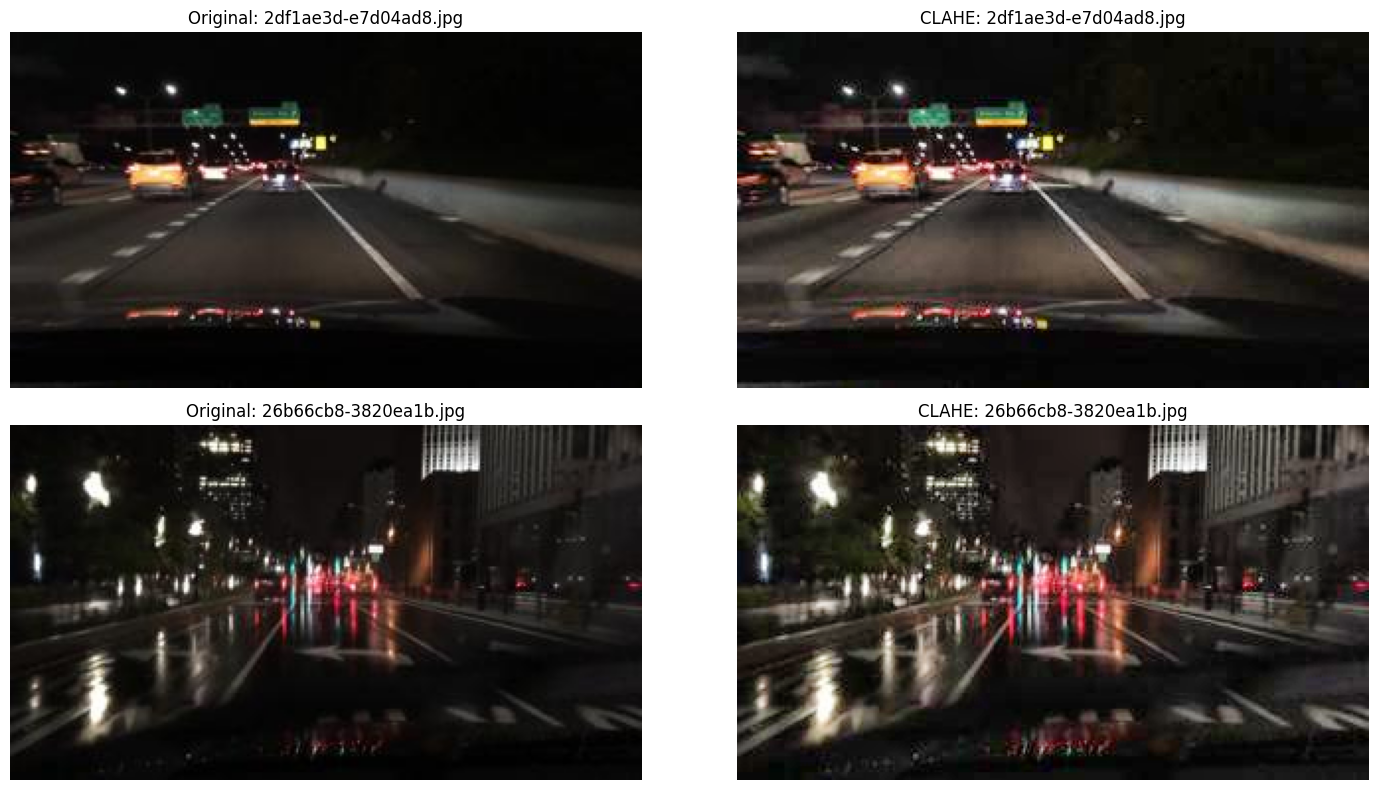


Todas las imágenes con filtro CLAHE procesadas y guardadas en: /content/dataset_night_clahe


In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

ruta_dataset_noche = '/content/dataset_night'
ruta_dataset_noche_clahe = '/content/dataset_night_clahe'

os.makedirs(ruta_dataset_noche_clahe, exist_ok=True)
print(f"Carpeta '{ruta_dataset_noche_clahe}' creada para guardar las imágenes con CLAHE.")

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

archivos_noche = [f for f in os.listdir(ruta_dataset_noche) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print(f"Total de imágenes de noche encontradas: {len(archivos_noche)}")

n_imagenes_a_mostrar = 2

plt.figure(figsize=(15, 8))

for i, filename in enumerate(archivos_noche):
    original_path = os.path.join(ruta_dataset_noche, filename)
    clahe_path = os.path.join(ruta_dataset_noche_clahe, filename)

    img_original_bgr = cv2.imread(original_path)
    if img_original_bgr is None:
        print(f"Error al cargar la imagen: {original_path}")
        continue

    img_hsv = cv2.cvtColor(img_original_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(img_hsv)
    v_clahe = clahe.apply(v)
    img_clahe_hsv = cv2.merge([h, s, v_clahe])
    img_clahe_bgr = cv2.cvtColor(img_clahe_hsv, cv2.COLOR_HSV2BGR)
    cv2.imwrite(clahe_path, img_clahe_bgr)
    if i < n_imagenes_a_mostrar:
        plt.subplot(n_imagenes_a_mostrar, 2, i*2 + 1)
        plt.imshow(cv2.cvtColor(img_original_bgr, cv2.COLOR_BGR2RGB))
        plt.title(f"Original: {filename}")
        plt.axis('off')

        plt.subplot(n_imagenes_a_mostrar, 2, i*2 + 2)
        plt.imshow(cv2.cvtColor(img_clahe_bgr, cv2.COLOR_BGR2RGB))
        plt.title(f"CLAHE: {filename}")
        plt.axis('off')

plt.tight_layout()
plt.show()

print(f"\nTodas las imágenes con filtro CLAHE procesadas y guardadas en: {ruta_dataset_noche_clahe}")


Aplica filtro Retinex a las imagenes de día y guarda en un nuevo directorio

Carpeta '/content/dataset_day_retinex' creada para guardar las imágenes con Retinex.
Total de imágenes de día encontradas: 36728


KeyboardInterrupt: 

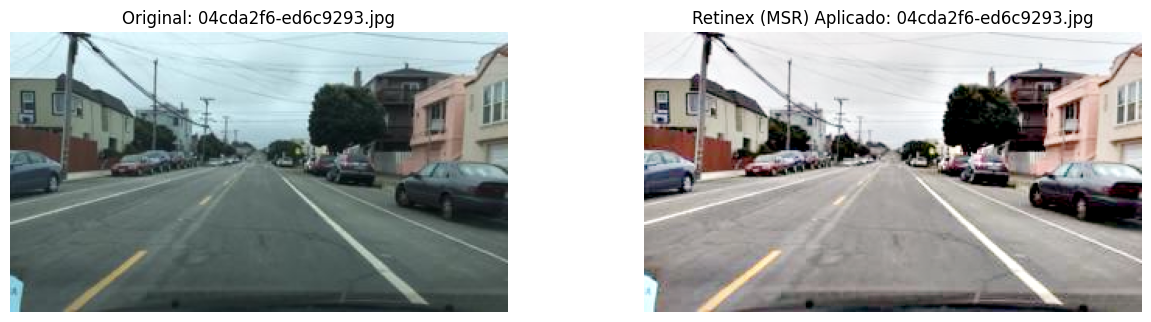

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

ruta_dataset_dia = '/content/dataset_day'
ruta_dataset_dia_retinex = '/content/dataset_day_retinex'
os.makedirs(ruta_dataset_dia_retinex, exist_ok=True)
print(f"Carpeta '{ruta_dataset_dia_retinex}' creada para guardar las imágenes con Retinex.")

def single_scale_retinex(img, sigma):

    img_float = img.astype(np.float64) + 1.0
    gauss = cv2.GaussianBlur(img, (0, 0), sigma).astype(np.float64) + 1.0
    return np.log10(img_float) - np.log10(gauss)
def multi_scale_retinex(img, sigma_list):
    retinex = np.zeros_like(img, dtype=np.float64)
    for sigma in sigma_list:
        retinex += single_scale_retinex(img, sigma)
    retinex = retinex / len(sigma_list)
    final_img = np.zeros_like(retinex)
    for i in range(img.shape[2]):
        channel = retinex[:, :, i]
        min_val = np.percentile(channel, 5.0)
        max_val = np.percentile(channel, 99.0)
        channel = np.clip(channel, min_val, max_val)
        final_img[:, :, i] = (channel - min_val) / (max_val - min_val) * 255

    return np.uint8(final_img)
archivos_dia = [f for f in os.listdir(ruta_dataset_dia) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print(f"Total de imágenes de día encontradas: {len(archivos_dia)}")

n_imagenes_a_mostrar = 2

plt.figure(figsize=(15, 8))

sigmas = [15, 80, 250]

for i, filename in enumerate(archivos_dia):
    original_path = os.path.join(ruta_dataset_dia, filename)
    retinex_path = os.path.join(ruta_dataset_dia_retinex, filename)

    img_original_bgr = cv2.imread(original_path)
    if img_original_bgr is None:
        print(f"Error al cargar la imagen: {original_path}")
        continue

    img_retinex_bgr = multi_scale_retinex(img_original_bgr, sigmas)
    cv2.imwrite(retinex_path, img_retinex_bgr)
    if i < n_imagenes_a_mostrar:
        plt.subplot(n_imagenes_a_mostrar, 2, i*2 + 1)
        plt.imshow(cv2.cvtColor(img_original_bgr, cv2.COLOR_BGR2RGB))
        plt.title(f"Original: {filename}")
        plt.axis('off')

        plt.subplot(n_imagenes_a_mostrar, 2, i*2 + 2)
        plt.imshow(cv2.cvtColor(img_retinex_bgr, cv2.COLOR_BGR2RGB))
        plt.title(f"Retinex (MSR) Aplicado: {filename}")
        plt.axis('off')

plt.tight_layout()
plt.show()

print(f"\nTodas las imágenes con filtro Retinex (MSR) procesadas y guardadas en: {ruta_dataset_dia_retinex}")
